# Prueba de Medias
Verifica que la media de la secuencia pseudoaleatoria sea estadísticamente 
cercana a 0.5, valor esperado de una distribución uniforme U(0,1).


In [130]:
import math

In [131]:
def prueba_medias(secuencia, nivel_confianza=0.95):
    """
    Parámetros:
        secuencia: lista de números pseudoaleatorios entre 0 y 1
        nivel_confianza: nivel de confianza para la prueba (default 95%)
    Retorna:
        resultado: diccionario con todos los valores calculados
    """
    # Número de elementos en la secuencia
    N = len(secuencia)
    
    # Calcular la media muestral
    media_muestral = sum(secuencia) / N
    
    # Valor Z para nivel de confianza del 95% (constante fija)
    z = 1.96
    
    # Media teórica para U(0,1)
    media_teorica = 0.5
    
    # Intervalo de confianza
    margen = z * (1 / math.sqrt(12 * N))
    limite_inferior = media_teorica - margen
    limite_superior = media_teorica + margen
    
    # Verificar si la secuencia pasa la prueba
    aprueba = limite_inferior <= media_muestral <= limite_superior
    
    # Retornar todos los resultados como diccionario
    return {
        "N": N,
        "media_muestral": round(media_muestral, 6),
        "media_teorica": media_teorica,
        "valor_z": z,
        "margen": round(margen, 6),
        "limite_inferior": round(limite_inferior, 6),
        "limite_superior": round(limite_superior, 6),
        "aprueba": aprueba
    }

In [132]:
secuencia_prueba = [0.23, 0.87, 0.41, 0.65, 0.12, 0.55, 0.34, 0.78, 0.91, 0.06]
resultado = prueba_medias(secuencia_prueba)

for clave, valor in resultado.items():
    print(f"{clave}: {valor}")

N: 10
media_muestral: 0.492
media_teorica: 0.5
valor_z: 1.96
margen: 0.178923
limite_inferior: 0.321077
limite_superior: 0.678923
aprueba: True


In [133]:
import matplotlib.pyplot as plt 

def grafico_prueba_medias(resultado):
    """
    Parámetros:
    resultado: diccionario retornado por la funciòn prueba_medias()
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Linea de la media teórica
    ax.axhline(y=resultado["media_teorica"], color= 'blue', linestyle='--', label='Media Teórica (0.5)')

    # Intervalo de confianza 
    ax.axhspan(resultado["limite_inferior"], resultado["limite_superior"], alpha=0.2, color='green', label='Intervalo de Confianza 95%')

    # Líneas de los límites
    ax.axhline(y=resultado["limite_inferior"], color="green", 
               linestyle=":", linewidth=1)
    ax.axhline(y=resultado["limite_superior"], color="green", 
               linestyle=":", linewidth=1)
    
    # Punto de la media muestral
    color_punto = "blue" if resultado["aprueba"] else "red"
    ax.plot(0.5, resultado["media_muestral"], "o", 
            color=color_punto, markersize=12, 
            label=f"Media muestral ({resultado['media_muestral']})")
    # Etiquetas y formato
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title("Prueba de Medias", fontsize=14, fontweight="bold")
    ax.set_ylabel("Valor", fontsize=12)
    ax.set_xticks([])
    ax.legend(loc="upper right")
    
    # Resultado en el gráfico
    texto = "APRUEBA ✓" if resultado["aprueba"] else "FALLA ✗"
    color_texto = "green" if resultado["aprueba"] else "red"
    ax.text(0.5, 0.1, texto, transform=ax.transAxes, 
            fontsize=14, color=color_texto, 
            ha="center", fontweight="bold")
    
    plt.tight_layout()
    plt.savefig("grafico_prueba_medias.png", dpi=150)
    plt.show()

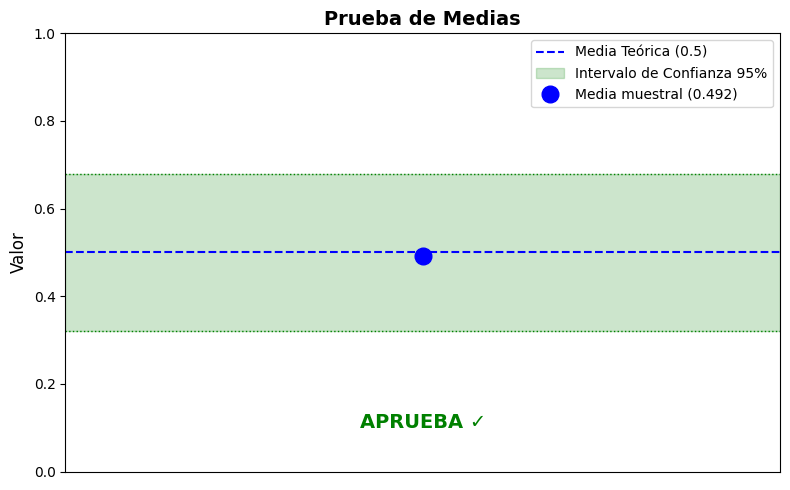

In [134]:
grafico_prueba_medias(resultado)

## Prueba de Varianza
Verifica que la varianza de la secuencia pseudoaleatoria sea estadísticamente 
cercana a 1/12 ≈ 0.0833, valor esperado de una distribución uniforme U(0,1).

In [135]:
!pip install scipy

In [136]:
import math


In [137]:
from scipy.stats import chi2
def prueba_varianza(secuencia, nivel_confianza=0.95):
    """
    Parámetros:
        secuencia: lista de números pseudoaleatorios entre 0 y 1
        nivel_confianza: nivel de confianza para la prueba (default 95%)
    Retorna:
        resultado: diccionario con todos los valores calculados
    """
    # Número de elementos en la secuencia
    N = len(secuencia)
    
    # Media muestral
    media = sum(secuencia) / N
    
    # Varianza muestral (igual que VAR.S de Excel)
    varianza_muestral = sum((x - media) ** 2 for x in secuencia) / (N - 1)
    
    # Varianza teórica para U(0,1)
    varianza_teorica = 1 / 12
    
    # Nivel de significancia
    alpha = 1 - nivel_confianza
    
    # Grados de libertad
    gl = N - 1
    
    # Valores críticos Chi-cuadrado exactos (igual que CHIINV de Excel)
    chi2_inferior = chi2.ppf(alpha / 2, gl)
    chi2_superior = chi2.ppf(1 - alpha / 2, gl)
    
    # Intervalo de confianza para la varianza
    limite_inferior = chi2_inferior / (12 * gl)
    limite_superior = chi2_superior / (12 * gl)
    
    # Verificar si la secuencia pasa la prueba
    aprueba = limite_inferior <= varianza_muestral <= limite_superior
    
    return {
        "N": N,
        "varianza_muestral": round(varianza_muestral, 6),
        "varianza_teorica": round(varianza_teorica, 6),
        "alpha": alpha,
        "grados_libertad": gl,
        "chi2_inferior": round(chi2_inferior, 6),
        "chi2_superior": round(chi2_superior, 6),
        "limite_inferior": round(limite_inferior, 6),
        "limite_superior": round(limite_superior, 6),
        "aprueba": aprueba
    }

In [138]:
secuencia_prueba = [
    0.23, 0.87, 0.41, 0.65, 0.12, 0.55, 0.34, 0.78, 0.91, 0.06,
    0.47, 0.83, 0.19, 0.72, 0.38, 0.61, 0.94, 0.27, 0.53, 0.16,
    0.69, 0.44, 0.88, 0.31, 0.57, 0.73, 0.08, 0.95, 0.22, 0.64,
    0.39, 0.81, 0.14, 0.58, 0.76, 0.03, 0.92, 0.47, 0.29, 0.68,
    0.51, 0.84, 0.17, 0.63, 0.35, 0.79, 0.42, 0.96, 0.11, 0.57,
    0.28, 0.74, 0.45, 0.89, 0.21, 0.66, 0.37, 0.82, 0.13, 0.59,
    0.71, 0.04, 0.93, 0.48, 0.26, 0.67, 0.52, 0.85, 0.18, 0.62,
    0.33, 0.77, 0.43, 0.97, 0.09, 0.54, 0.76, 0.31, 0.86, 0.24,
    0.61, 0.15, 0.70, 0.46, 0.90, 0.25, 0.58, 0.80, 0.36, 0.69,
    0.05, 0.98, 0.32, 0.75, 0.49, 0.20, 0.63, 0.88, 0.40, 0.73
]
resultado_varianza = prueba_varianza(secuencia_prueba)

for clave, valor in resultado_varianza.items():
    print(f"{clave}: {valor}")

N: 100
varianza_muestral: 0.073612
varianza_teorica: 0.083333
alpha: 0.050000000000000044
grados_libertad: 99
chi2_inferior: 73.36108
chi2_superior: 128.421989
limite_inferior: 0.061752
limite_superior: 0.108099
aprueba: True


In [139]:
def grafico_prueba_varianza(resultado):
    """"
    Parámetros: 
    resultado: diccionario retornado por la función prueba_varianza()
    """
    fig, ax = plt.subplots(figsize=(8, 5))    
    # Línea de la varianza teórica
    ax.axhline(y=resultado["varianza_teorica"], color="blue",
               linestyle="--", label=f"Varianza teórica (1/12 ≈ {resultado['varianza_teorica']})")
    
    # Intervalo de confianza como franja
    ax.axhspan(resultado["limite_inferior"], resultado["limite_superior"],
               alpha=0.2, color="green", label="Intervalo de confianza 95%")
    
    # Líneas de los límites
    ax.axhline(y=resultado["limite_inferior"], color="green",
               linestyle=":", linewidth=1)
    ax.axhline(y=resultado["limite_superior"], color="green",
               linestyle=":", linewidth=1)
    
    # Punto de la varianza muestral
    color_punto = "blue" if resultado["aprueba"] else "red"
    ax.plot(0.5, resultado["varianza_muestral"], "o",
            color=color_punto, markersize=12,
            label=f"Varianza muestral ({resultado['varianza_muestral']})")
    
    # Etiquetas y formato
    ax.set_xlim(0, 1)
    ax.set_ylim(0, resultado["limite_superior"] + 0.05)
    ax.set_title("Prueba de Varianza", fontsize=14, fontweight="bold")
    ax.set_ylabel("Valor", fontsize=12)
    ax.set_xticks([])
    ax.legend(loc="upper right")
    
    # Resultado en el gráfico
    texto = "APRUEBA ✓" if resultado["aprueba"] else "FALLA ✗"
    color_texto = "green" if resultado["aprueba"] else "red"
    ax.text(0.5, 0.1, texto, transform=ax.transAxes,
            fontsize=14, color=color_texto,
            ha="center", fontweight="bold")
    
    plt.tight_layout()
    plt.savefig("grafico_prueba_varianza.png", dpi=150)
    plt.show()

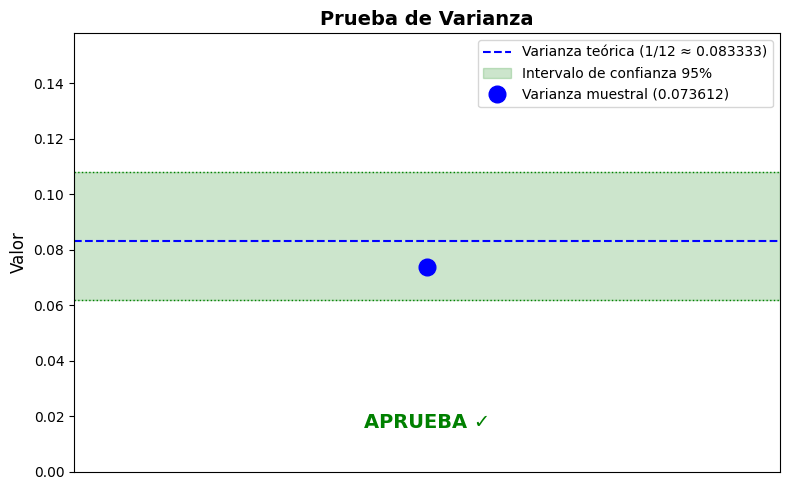

In [140]:
resultado_varianza = prueba_varianza(secuencia_prueba)
grafico_prueba_varianza(resultado_varianza)

## Prueba Chi-Cuadrado
Verifica que los números pseudoaleatorios se distribuyan de manera uniforme en el intervalo [0,1], comparando las frecuencias observadas en cada subintervalo contra las frecuencias esperadas teóricas

In [141]:
import math

In [142]:
def prueba_chi_cuadrado(secuencia, k=10, nivel_de_confianza=0.95):
    """"
    Parametros:
        secuencia: Lista de números pseudoaleatorios entre 0 y 1
        k: Número de intervalos (default 10)
        nivel_confianza: nivel de confianza para la prueba(default 95%)
    Retorna:
        resultado: diccionario con todos los valores calculados
    """
    # Número de elementos en la secuencia
    N = len(secuencia)

    # Frecuencia esperada en cada intervalo
    frecuencia_esperada = N / k

    # Contar frecuancias observadas en cada intervalo
    frecuencias_observadas = [0] * k
    for numero in secuencia:
        indice = int(numero * k)
        if indice == k: # caso borde: cuando numero es exactamente 1.0
            indice = k - 1
        frecuencias_observadas[indice] += 1
        
    # Calcular estadístico chi-cuadrado
    chi2_calculado = sum((obs -frecuencia_esperada) ** 2 / frecuencia_esperada
    for obs in frecuencias_observadas
    )

    # Valor crítico chi-cuadrado para k-1 grados de libertad al 95 %
    # Aproximacion de Wilson-Hilferty
    gl = k - 1
    chi2_critico = gl * (1 - 2/(9*gl) + 1.96 * math.sqrt(2/(9*gl))) ** 3
    
    #Verificar si la secuencia pasa la prueba
    aprueba = chi2_calculado < chi2_critico

    # Retornar todos los resultados como diccionario
    return {
        "N": N,
        "k": k,
        "frecuencias_observadas": frecuencias_observadas,
        "frecuencia_esperada": round(frecuencia_esperada, 6),
        "chi2_calculado": round(chi2_calculado, 6),
        "chi2_critico": round(chi2_critico, 6),
        "grados_libertad": gl,
        "aprueba": aprueba
    }

In [143]:
secuencia_prueba = [
    0.23, 0.87, 0.41, 0.65, 0.12, 0.55, 0.34, 0.78, 0.91, 0.06,
    0.47, 0.83, 0.19, 0.72, 0.38, 0.61, 0.94, 0.27, 0.53, 0.16,
    0.69, 0.44, 0.88, 0.31, 0.57, 0.73, 0.08, 0.95, 0.22, 0.64,
    0.39, 0.81, 0.14, 0.58, 0.76, 0.03, 0.92, 0.47, 0.29, 0.68,
    0.51, 0.84, 0.17, 0.63, 0.35, 0.79, 0.42, 0.96, 0.11, 0.57,
    0.28, 0.74, 0.45, 0.89, 0.21, 0.66, 0.37, 0.82, 0.13, 0.59,
    0.71, 0.04, 0.93, 0.48, 0.26, 0.67, 0.52, 0.85, 0.18, 0.62,
    0.33, 0.77, 0.43, 0.97, 0.09, 0.54, 0.76, 0.31, 0.86, 0.24,
    0.61, 0.15, 0.70, 0.46, 0.90, 0.25, 0.58, 0.80, 0.36, 0.69,
    0.05, 0.98, 0.32, 0.75, 0.49, 0.20, 0.63, 0.88, 0.40, 0.73
]

resultado_chi = prueba_chi_cuadrado(secuencia_prueba)

for clave, valor in resultado_chi.items():
    print(f"{clave}: {valor}")

N: 100
k: 10
frecuencias_observadas: [6, 9, 10, 10, 11, 10, 12, 12, 11, 9]
frecuencia_esperada: 10.0
chi2_calculado: 2.8
chi2_critico: 19.020412
grados_libertad: 9
aprueba: True


In [144]:
def grafico_prueba_chi_cuadrado(resultado):
    """
    Parámetros:
        resultado: diccionario retornado por prueba_chi_cuadrado()
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    
    k = resultado["k"]
    intervalos = [f"{i/k:.1f}-{(i+1)/k:.1f}" for i in range(k)]
    frecuencias_observadas = resultado["frecuencias_observadas"]
    frecuencia_esperada = resultado["frecuencia_esperada"]
    
    # Posiciones de las barras
    x = range(k)
    ancho = 0.35
    
    # Barras de frecuencias observadas y esperadas
    barras_obs = ax.bar([i - ancho/2 for i in x], frecuencias_observadas, 
                        ancho, label="Frecuencia observada", color="steelblue")
    barras_esp = ax.bar([i + ancho/2 for i in x], [frecuencia_esperada] * k, 
                        ancho, label="Frecuencia esperada", color="orange", alpha=0.7)
    
    # Etiquetas encima de las barras observadas
    for barra in barras_obs:
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.1,
                str(int(barra.get_height())), ha="center", va="bottom", fontsize=9)
    
    # Formato
    ax.set_xticks(list(x))
    ax.set_xticklabels(intervalos, rotation=45, ha="right")
    ax.set_xlabel("Intervalos", fontsize=12)
    ax.set_ylabel("Frecuencia", fontsize=12)
    ax.set_title("Prueba Chi-Cuadrado: Frecuencias Observadas vs Esperadas", 
                 fontsize=14, fontweight="bold")
    ax.legend()
    
    # Información estadística
    ax.text(0.98, 0.95, 
            f"χ² calculado = {resultado['chi2_calculado']}\n"
            f"χ² crítico = {resultado['chi2_critico']}\n"
            f"Grados de libertad = {resultado['grados_libertad']}",
            transform=ax.transAxes, fontsize=10,
            verticalalignment="top", horizontalalignment="right",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    
    # Resultado en el gráfico
    texto = "APRUEBA ✓" if resultado["aprueba"] else "FALLA ✗"
    color_texto = "green" if resultado["aprueba"] else "red"
    ax.text(0.02, 0.95, texto, transform=ax.transAxes,
            fontsize=14, color=color_texto,
            verticalalignment="top", fontweight="bold")
    
    plt.tight_layout()
    plt.savefig("grafico_prueba_chi_cuadrado.png", dpi=150)
    plt.show()

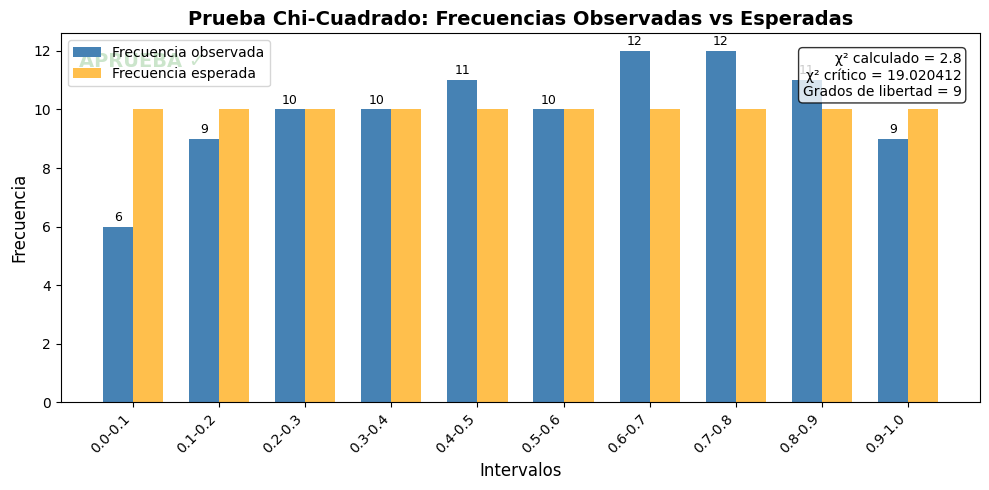

In [145]:
grafico_prueba_chi_cuadrado(resultado_chi)

## Prueba de Kolmogorov-Smirnov (KS)
Verifica que la distribución acumulada de la secuencia pseudoaleatoria se ajuste a la distribución unifome teórica U(0,1), comparando las frecuencias acumuladas observadas contra las esperadas por intervalo y calculando la máxima diferencia entre ambas.

In [146]:
import math

In [147]:
def prueba_ks(secuencia, k=10):
    """
    Parámetros:
        secuencia: lista de números pseudoaleatorios entre 0 y 1
        k: número de intervalos (default 10)
        nivel_confianza: nivel de confianza para la prueba(default 95%)
    Retorna: 
            resultado: diccionario con todos los valores calcuados
            """
    # Número de elementos en la secuencia
    N = len(secuencia)
    
    # Frecuencia esperada por intervalo
    frec_esperada = N / k

    # Contar frecuencias observadas por intervalo
    frecuencias_observadas = [0] * k
    for numero in secuencia:
        indice = int(numero * k)
        if indice == k :
            indice = k - 1
        frecuencias_observadas[indice] += 1

    #Calcular frecuencias acumuladas y diferencias
    tabla = []
    frec_obs_acumulada = 0
    frec_esp_acumulada = 0
    for i in range(k):
        limite_inicial = round(i / k, 2)
        limite_final = round((i + 1) / k, 2)
        
        frec_obs_acumulada += frecuencias_observadas[i]
        frec_esp_acumulada += frec_esperada
        
        p_obs_acumulada = frec_obs_acumulada / N
        p_esp_acumulada = frec_esp_acumulada / N
        
        diferencia = abs(p_obs_acumulada - p_esp_acumulada)
        
        tabla.append({          # ← debe estar aquí adentro
            "intervalo": f"{limite_inicial}-{limite_final}",
            "frec_observada": frecuencias_observadas[i],
            "frec_obs_acumulada": frec_obs_acumulada,
            "p_obs_acumulada": round(p_obs_acumulada, 6),
            "frec_esp_acumulada": frec_esp_acumulada,
            "p_esp_acumulada": round(p_esp_acumulada, 6),
            "diferencia": round(diferencia, 6)
        })

    #DMAX: la diferencia mas grande
    dmax = max(fila["diferencia"] for fila in tabla)

    #DMAXP: valor cítico
    dmaxp = 1.36 /math.sqrt(N)

    #Verifica si la secuencia aprueba
    aprueba = dmax < dmaxp
    return {
    "N": N,
    "k": k,
    "tabla": tabla,
    "dmax": round(dmax, 6),
    "dmaxp": round(dmaxp, 6),
    "aprueba": aprueba
    }

        

In [148]:
secuencia_prueba = [
    0.23, 0.87, 0.41, 0.65, 0.12, 0.55, 0.34, 0.78, 0.91, 0.06,
    0.47, 0.83, 0.19, 0.72, 0.38, 0.61, 0.94, 0.27, 0.53, 0.16,
    0.69, 0.44, 0.88, 0.31, 0.57, 0.73, 0.08, 0.95, 0.22, 0.64,
    0.39, 0.81, 0.14, 0.58, 0.76, 0.03, 0.92, 0.47, 0.29, 0.68,
    0.51, 0.84, 0.17, 0.63, 0.35, 0.79, 0.42, 0.96, 0.11, 0.57,
    0.28, 0.74, 0.45, 0.89, 0.21, 0.66, 0.37, 0.82, 0.13, 0.59,
    0.71, 0.04, 0.93, 0.48, 0.26, 0.67, 0.52, 0.85, 0.18, 0.62,
    0.33, 0.77, 0.43, 0.97, 0.09, 0.54, 0.76, 0.31, 0.86, 0.24,
    0.61, 0.15, 0.70, 0.46, 0.90, 0.25, 0.58, 0.80, 0.36, 0.69,
    0.05, 0.98, 0.32, 0.75, 0.49, 0.20, 0.63, 0.88, 0.40, 0.73
]

resultado_ks = prueba_ks(secuencia_prueba)

print(f"N: {resultado_ks['N']}")
print(f"DMAX: {resultado_ks['dmax']}")
print(f"DMAXP: {resultado_ks['dmaxp']}")
print(f"Aprueba: {resultado_ks['aprueba']}")
print("\n--- Tabla de intervalos ---")
print(f"{'Intervalo':<12} {'F.Obs':>6} {'F.Obs.Ac':>9} {'P.Obs.Ac':>9} {'F.Esp.Ac':>9} {'P.Esp.Ac':>9} {'Dif':>9}")
for fila in resultado_ks['tabla']:
    print(f"{fila['intervalo']:<12} {fila['frec_observada']:>6} {fila['frec_obs_acumulada']:>9} {fila['p_obs_acumulada']:>9} {fila['frec_esp_acumulada']:>9} {fila['p_esp_acumulada']:>9} {fila['diferencia']:>9}")


# Diagnóstico
N = len(secuencia_prueba)
k = 10
frecuencias_observadas = [0] * k

for numero in secuencia_prueba:
    indice = int(numero * k)
    if indice == k:
        indice = k - 1
    frecuencias_observadas[indice] += 1

print(f"Total números: {N}")
print(f"Frecuencias por intervalo: {frecuencias_observadas}")
print(f"Suma total: {sum(frecuencias_observadas)}")


N: 100
DMAX: 0.05
DMAXP: 0.136
Aprueba: True

--- Tabla de intervalos ---
Intervalo     F.Obs  F.Obs.Ac  P.Obs.Ac  F.Esp.Ac  P.Esp.Ac       Dif
0.0-0.1           6         6      0.06      10.0       0.1      0.04
0.1-0.2           9        15      0.15      20.0       0.2      0.05
0.2-0.3          10        25      0.25      30.0       0.3      0.05
0.3-0.4          10        35      0.35      40.0       0.4      0.05
0.4-0.5          11        46      0.46      50.0       0.5      0.04
0.5-0.6          10        56      0.56      60.0       0.6      0.04
0.6-0.7          12        68      0.68      70.0       0.7      0.02
0.7-0.8          12        80       0.8      80.0       0.8       0.0
0.8-0.9          11        91      0.91      90.0       0.9      0.01
0.9-1.0           9       100       1.0     100.0       1.0       0.0
Total números: 100
Frecuencias por intervalo: [6, 9, 10, 10, 11, 10, 12, 12, 11, 9]
Suma total: 100


In [149]:
def grafico_prueba_ks(resultado):
    """
    Parámetros:
        resultado: diccionario retornado por prueba_ks()
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    
    intervalos = [fila["intervalo"] for fila in resultado["tabla"]]
    p_obs = [fila["p_obs_acumulada"] for fila in resultado["tabla"]]
    p_esp = [fila["p_esp_acumulada"] for fila in resultado["tabla"]]
    diferencias = [fila["diferencia"] for fila in resultado["tabla"]]
    
    # Línea de proporción acumulada observada
    ax.plot(intervalos, p_obs, marker="o", color="steelblue",
            linewidth=2, label="P. Acumulada Observada")
    
    # Línea de proporción acumulada esperada
    ax.plot(intervalos, p_esp, marker="s", color="orange",
            linewidth=2, linestyle="--", label="P. Acumulada Esperada")
    
    # Marcar la diferencia máxima (DMAX)
    indice_dmax = diferencias.index(max(diferencias))
    ax.annotate(f"DMAX = {resultado['dmax']}",
                xy=(intervalos[indice_dmax], p_obs[indice_dmax]),
                xytext=(indice_dmax + 0.5, p_obs[indice_dmax] - 0.1),
                arrowprops=dict(arrowstyle="->", color="red"),
                fontsize=10, color="red")
    
    # Formato
    ax.set_xticks(range(len(intervalos)))
    ax.set_xticklabels(intervalos, rotation=45, ha="right")
    ax.set_xlabel("Intervalos", fontsize=12)
    ax.set_ylabel("Proporción Acumulada", fontsize=12)
    ax.set_title("Prueba Kolmogorov-Smirnov: FEC Observada vs Esperada",
                 fontsize=14, fontweight="bold")
    ax.legend()
    
    # Información estadística
    ax.text(0.02, 0.95,
            f"DMAX = {resultado['dmax']}\n"
            f"DMAXP = {resultado['dmaxp']}\n"
            f"n = {resultado['N']}",
            transform=ax.transAxes, fontsize=10,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    
    # Resultado en el gráfico
    texto = "APRUEBA ✓" if resultado["aprueba"] else "FALLA ✗"
    color_texto = "green" if resultado["aprueba"] else "red"
    ax.text(0.98, 0.05, texto, transform=ax.transAxes,
            fontsize=14, color=color_texto,
            ha="right", fontweight="bold")
    
    plt.tight_layout()
    plt.savefig("grafico_prueba_ks.png", dpi=150)
    plt.show()

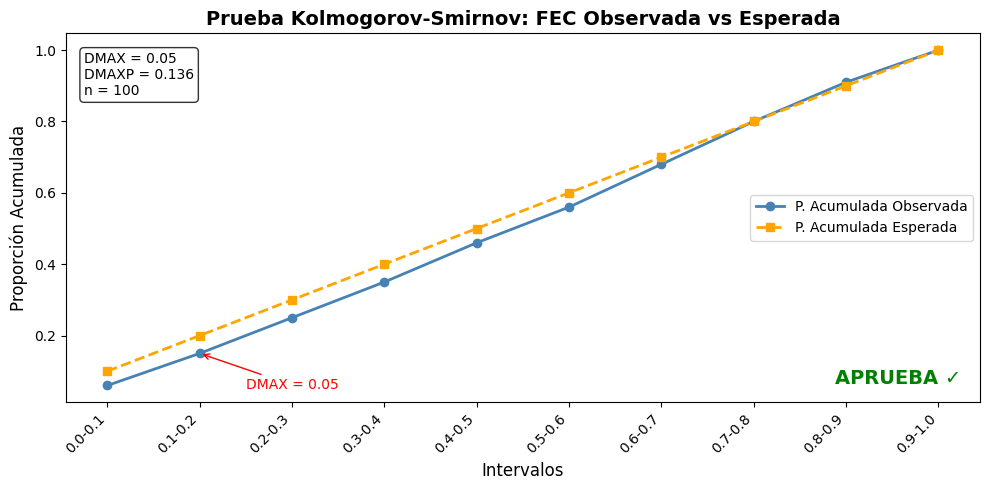

In [150]:
grafico_prueba_ks(resultado_ks)

## Prueba de Poker
Veriica la independencia de los nùmeros pseudoaleatorios analizando los patrone formados por sus 5 dìgitos decimales significativos, comparando las frecuencias observadas de cada categorìa contra las frecuencias esperadas teòricas mediante un estadìstico Chi-cuadrado.

In [151]:
from scipy.stats import chi2

In [152]:
def prueba_poker(secuencia, nivel_confianza=0.95):
    """
    Parámetros: 
        secuencia: lista de números pseudoaleatorios entre 0 y 1
        nivel_confianza: nivel de confianza para la prueba (default 95%)
    Retorna:
        resultado: diccionario con todos los problemas calculados
    """

    # Número de elementos en la secuencia
    N = len(secuencia)

    # Probabilidades teóricas de cada categoría 
    categorias = {
        "D - Todos diferentes": 0.3024,
        "O - Un par": 0.5040,
        "T - Dos Pares": 0.1080,
        "K - Tercia": 0.0720,
        "F - Full House": 0.0090,
        "P - Poker": 0.0045,
        "Q - Quintilla": 0.0001
     }
    
    #Frecuencias observadas inicializadas en 0
    frecuencias_observadas = {cat: 0 for cat in categorias}

    #Clasificar cada número
    for numero in secuencia:
        # Extraer 5 dígitos decimales significativos
        digitos = str(int(round(numero * 100000))).zfill(5)
        digitos = digitos[:5]
    
        #Contar repeticiones de cada dígito
        conteo = {}
        for d in digitos:
            conteo[d] = conteo.get(d, 0) + 1
        
        frecuencias =  sorted(conteo.values(), reverse=True)

        # Clasificar según el patrón
        if frecuencias[0] == 5:
            frecuencias_observadas["Q - Quintilla"] += 1
        elif frecuencias[0] == 4:
            frecuencias_observadas["P - Poker"] +=1
        elif frecuencias[0] == 3 and frecuencias[1] == 2:
            frecuencias_observadas["F - Full House"] += 1
        elif frecuencias[0] == 3:
            frecuencias_observadas["K - Tercia"] += 1
        elif frecuencias[0] == 2 and frecuencias[1] == 2:
            frecuencias_observadas["T - Dos Pares"] += 1
        elif frecuencias[0] ==  2:
            frecuencias_observadas["O - Un par"] += 1
        else:
            frecuencias_observadas["D - Todos diferentes"] += 1
    
    # Calcular frecuencias esperadas y estadístico chi-cuadrado
    tabla  = []
    chi2_calculado = 0

    for cat, prob in categorias.items():
        obs = frecuencias_observadas[cat]
        esp = N * prob
        chi2_calculado += (obs - esp) ** 2 / esp
        tabla.append({
            "categoria": cat,
            "frecuencia_observada": obs,
            "probabilidad": prob,
            "frecuencia_esperada": round(esp,4),
            "contribucion_chi2": round((obs - esp) ** 2 / esp, 6)
        })
    # Valor crítico chi-cuadrado para 6 grados de libertad al 95%
    chi2_critico = chi2.ppf (nivel_confianza, 6)

    #Verificar si la secuencia pasa la prueba
    aprueba = chi2_calculado <  chi2_critico
        
    return{
        "N": N,
        "tabla": tabla,
        "chi2_calculado": round(chi2_calculado, 6),
        "chi2_critico": round(chi2_critico, 6),
        "grados_libertad": 6,
        "aprueba": aprueba
    }
# Diagnóstico: ver cómo se clasifica cada número
for numero in secuencia_prueba:
    digitos = str(int(round(numero * 100000))).zfill(5)[:5]
    conteo = {}
    for d in digitos:
        conteo[d] = conteo.get(d, 0) + 1
    frecuencias = sorted(conteo.values(), reverse=True)
    
    if frecuencias[0] == 2 and len(frecuencias) > 1 and frecuencias[1] < 2:
        print(f"{numero} → dígitos: {digitos} → Un par")


In [153]:
import random
random.seed(42)
secuencia_prueba_poker = [round(random.random(), 5) for _ in range(1000)]
resultado_poker = prueba_poker(secuencia_prueba_poker)



In [154]:
def grafico_prueba_poker(resultado):
    """
    Parámetros:
        resultado: diccionario retornado por prueba_poker()
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    
    categorias = [fila["categoria"] for fila in resultado["tabla"]]
    frec_obs = [fila["frecuencia_observada"] for fila in resultado["tabla"]]
    frec_esp = [fila["frecuencia_esperada"] for fila in resultado["tabla"]]
    
    # Posiciones de las barras
    x = range(len(categorias))
    ancho = 0.35
    
    # Barras de frecuencias observadas y esperadas
    barras_obs = ax.bar([i - ancho/2 for i in x], frec_obs,
                        ancho, label="Frecuencia observada", color="steelblue")
    barras_esp = ax.bar([i + ancho/2 for i in x], frec_esp,
                        ancho, label="Frecuencia esperada", color="orange", alpha=0.7)
    
    # Etiquetas encima de las barras observadas
    for barra in barras_obs:
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.5,
                str(int(barra.get_height())), ha="center", va="bottom", fontsize=9)
    
    # Formato
    ax.set_xticks(list(x))
    ax.set_xticklabels(categorias, rotation=45, ha="right")
    ax.set_xlabel("Categorías", fontsize=12)
    ax.set_ylabel("Frecuencia", fontsize=12)
    ax.set_title("Prueba de Póker: Frecuencias Observadas vs Esperadas",
                 fontsize=14, fontweight="bold")
    ax.legend()
    
    # Información estadística
    ax.text(0.98, 0.95,
            f"χ² calculado = {resultado['chi2_calculado']}\n"
            f"χ² crítico = {resultado['chi2_critico']}\n"
            f"Grados de libertad = {resultado['grados_libertad']}",
            transform=ax.transAxes, fontsize=10,
            verticalalignment="top", horizontalalignment="right",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    
    # Resultado en el gráfico
    texto = "APRUEBA ✓" if resultado["aprueba"] else "FALLA ✗"
    color_texto = "green" if resultado["aprueba"] else "red"
    ax.text(0.02, 0.95, texto, transform=ax.transAxes,
            fontsize=14, color=color_texto,
            verticalalignment="top", fontweight="bold")
    
    plt.tight_layout()
    plt.savefig("grafico_prueba_poker.png", dpi=150)
    plt.show()
    

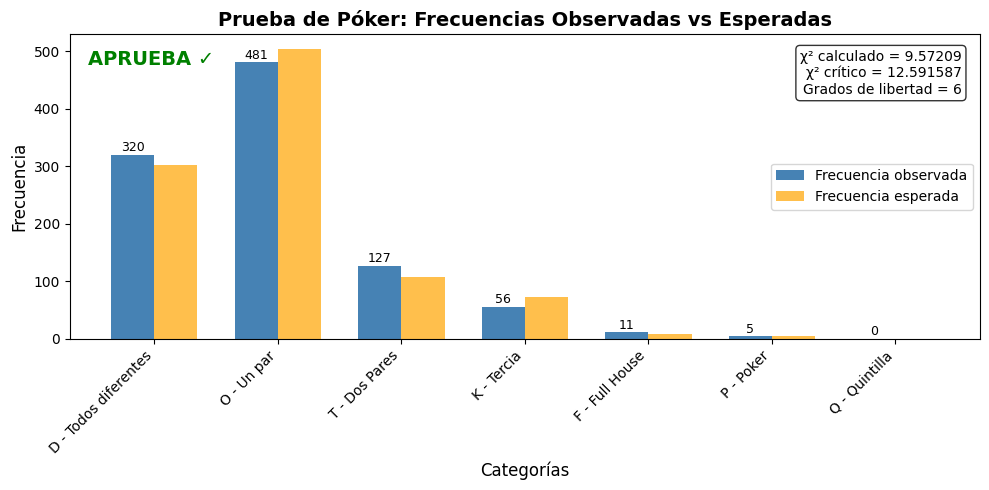

In [155]:
grafico_prueba_poker(resultado_poker)

## Prueba de Rachas
Verifica  la aleatoriedad de la secuencia pseudoaleatoria detectanto patrones de agrupamiento por encima o por debajo de la mediana.
Clasifica cada número como (+) si es mayor o igual a la mediana y (-) si es menor, contando las rachas resultantes y comparando contra los valores esperados teóricos mediante un estadístico Z.

In [156]:
import math
from scipy.stats import norm

In [157]:

def prueba_rachas(secuencia, nivel_confianza=0.95):
    """"
    Parámetros:
        secuencia: lista de números pseudoaleatorios entre 0 y 1
        nivel_confianza: nivel de confianza para la prueba (default 95%)
    Retorna:
        resultado: diccionario con todos los valores calculados
    """
    # Número de elementos en la secuencia
    N = len(secuencia)

    #Calcular la mediana de la secuencia
    secuencia_ordenada = sorted(secuencia)
    if N % 2 == 0:
        mediana = ( secuencia_ordenada[N-1] + secuencia_ordenada[N//2]/2) /2
    else: 
        mediana = secuencia_ordenada[N//2]
    
    #Mediana Teórica para U(0,1)
    mediana_teorica= 0.5

    #Clasificar cada numero como + o -
    signos = []
    for numero in secuencia:
        if numero >= mediana:
            signos.append("+")
        else:
            signos.append("-")
    
    #Contar total de + y de - 
    n1 = signos.count("+")
    n2 = signos.count("-")

    #Contar rachas totales
    rachas= 1
    for i in range(1, len(signos)):
        if signos[i] != signos[i-1]:
            rachas +=1

    #Rachas esperadas
    rachas_esperadas =((2* n1 * n2)/ N) +1

    #Varianza esperada
    varianza_esperada= (2 * n1 * n2 * (2 * n1 * n2 - N)) / (N**2 * (N - 1))

    #Estadístico Z
    z_calculado = (rachas - rachas_esperadas ) / math.sqrt(varianza_esperada)

    #Valor crítico Z para 95% de confianza
    z_critico = norm.ppf(1 - (1 - nivel_confianza) / 2)                                    

    #Rango de aceptación
    rango_minimo = -z_critico
    rango_maximo = z_critico

    #Verificar si la secuencia pasa la prueba
    aprueba = rango_minimo <= z_calculado <= rango_maximo

    return {
        "N": N,
        "mediana": round(mediana, 6),
        "mediana_teorica": mediana_teorica,
        "n1_positivos": n1,
        "n2_negativos": n2,
        "rachas_observadas": rachas,
        "rachas_esperadas": round(rachas_esperadas, 6),
        "varianza_esperada": round(varianza_esperada, 6),
        "z_calculado": round(z_calculado, 6),
        "z_critico": z_critico,
        "rango_minimo": rango_minimo,
        "rango_maximo": rango_maximo,
        "aprueba": aprueba
    }




In [158]:
import random
random.seed(42)
secuencia_prueba_rachas = [round(random.random(), 5) for _ in range(100)]

resultado_rachas = prueba_rachas(secuencia_prueba_rachas)

for clave, valor in resultado_rachas.items():
    print(f"{clave}: {valor}")

N: 100
mediana: 0.62511
mediana_teorica: 0.5
n1_positivos: 36
n2_negativos: 64
rachas_observadas: 49
rachas_esperadas: 47.08
varianza_esperada: 20.982691
z_calculado: 0.419151
z_critico: 1.959963984540054
rango_minimo: -1.959963984540054
rango_maximo: 1.959963984540054
aprueba: True


In [159]:
def grafico_prueba_rachas(resultado):
    """
    Parámetros:
        resultado: diccionario retornado por prueba_rachas()
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Barras de rachas observadas y esperadas
    categorias = ["Rachas\nObservadas", "Rachas\nEsperadas"]
    valores = [resultado["rachas_observadas"], resultado["rachas_esperadas"]]
    colores = ["steelblue", "orange"]
    
    barras = ax.bar(categorias, valores, color=colores, 
                    width=0.4, edgecolor="black", linewidth=0.8)
    
    # Intervalo de confianza sobre las rachas esperadas
    margen = resultado["z_critico"] * math.sqrt(resultado["varianza_esperada"])
    ax.errorbar(1, resultado["rachas_esperadas"],
                yerr=margen, fmt="none",
                color="red", capsize=8, linewidth=2,
                label=f"Intervalo de confianza 95%\n(±{round(margen, 2)})")
    
    # Etiquetas encima de las barras
    for barra, valor in zip(barras, valores):
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.3,
                str(round(valor, 2)), ha="center", va="bottom", 
                fontsize=11, fontweight="bold")
    
    # Formato
    ax.set_ylabel("Número de Rachas", fontsize=12)
    ax.set_title("Prueba de Rachas: Observadas vs Esperadas",
                 fontsize=14, fontweight="bold")
    ax.legend(loc="upper right")
    ax.set_ylim(0, max(valores) + 15)
    
    # Información estadística
    ax.text(0.02, 0.95,
            f"Z calculado = {resultado['z_calculado']}\n"
            f"Z crítico = ±{round(resultado['z_critico'], 4)}\n"
            f"n1(+) = {resultado['n1_positivos']}\n"
            f"n2(-) = {resultado['n2_negativos']}\n"
            f"Mediana = {resultado['mediana']}",
            transform=ax.transAxes, fontsize=10,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    
    # Resultado en el gráfico
    texto = "APRUEBA ✓" if resultado["aprueba"] else "FALLA ✗"
    color_texto = "green" if resultado["aprueba"] else "red"
    ax.text(0.98, 0.05, texto, transform=ax.transAxes,
            fontsize=14, color=color_texto,
            ha="right", fontweight="bold")
    
    plt.tight_layout()
    plt.savefig("grafico_prueba_rachas.png", dpi=150)
    plt.show()

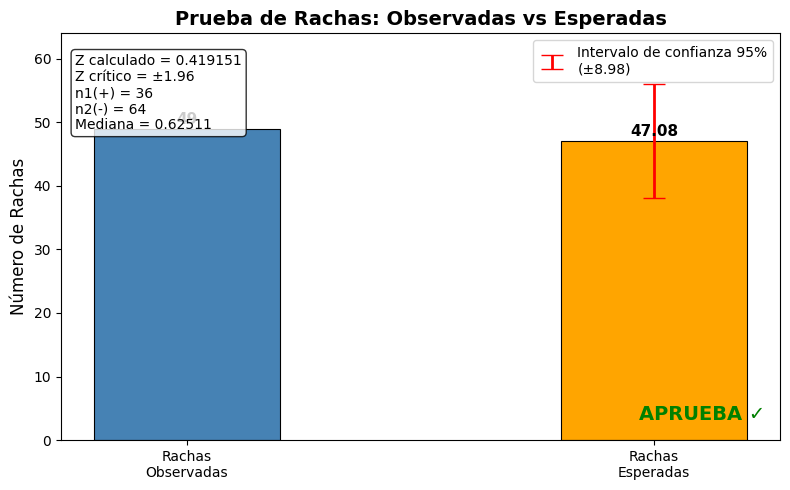

In [160]:
grafico_prueba_rachas(resultado_rachas)

In [163]:
import random
random.seed(42)
secuencia_prueba = [round(random.random(), 5) for _ in range(1000000)]

resultado_poker = prueba_poker(secuencia_prueba)
resultado_chi = prueba_chi_cuadrado(secuencia_prueba)
resultado_ks = prueba_ks(secuencia_prueba)
resultado_rachas = prueba_rachas(secuencia_prueba)
resultado_varianza = prueba_varianza(secuencia_prueba)
resultado = prueba_medias(secuencia_prueba)

for clave, valor in resultado.items():
    print(f"{clave}: {valor}")
for clave, valor in resultado_varianza.items():
    print(f"{clave}: {valor}")
for clave, valor in resultado_chi.items():
    print(f"{clave}: {valor}")
for clave, valor in resultado_ks.items():
    print(f"{clave}: {valor}")
for clave, valor in resultado_rachas.items():
    print(f"{clave}: {valor}")
for clave, valor in resultado_poker.items():
    print(f"{clave}: {valor}")

N: 1000000
media_muestral: 0.500015
media_teorica: 0.5
valor_z: 1.96
margen: 0.000566
limite_inferior: 0.499434
limite_superior: 0.500566
aprueba: True
N: 1000000
varianza_muestral: 0.083229
varianza_teorica: 0.083333
alpha: 0.050000000000000044
grados_libertad: 999999
chi2_inferior: 997229.088529
chi2_superior: 1002772.700082
limite_inferior: 0.083103
limite_superior: 0.083564
aprueba: True
N: 1000000
k: 10
frecuencias_observadas: [99882, 99745, 99870, 100304, 100019, 99915, 100491, 100391, 99654, 99729]
frecuencia_esperada: 100000.0
chi2_calculado: 7.8297
chi2_critico: 19.020412
grados_libertad: 9
aprueba: True
N: 1000000
k: 10
tabla: [{'intervalo': '0.0-0.1', 'frec_observada': 99882, 'frec_obs_acumulada': 99882, 'p_obs_acumulada': 0.099882, 'frec_esp_acumulada': 100000.0, 'p_esp_acumulada': 0.1, 'diferencia': 0.000118}, {'intervalo': '0.1-0.2', 'frec_observada': 99745, 'frec_obs_acumulada': 199627, 'p_obs_acumulada': 0.199627, 'frec_esp_acumulada': 200000.0, 'p_esp_acumulada': 0.2, 